##확률적 경사 하강법 (SGD)
확률적 경사 하강법은 해당 위치에서의 기울기를 이용해서 손실함수를 최대한 적게 하는 것을 목적으로 하는 최적화 방법입니다.

W <- W - n(aL / aW)
n= 학습률 (ex. 0.01, 0.001 등 미리 정해준 학습률)
W= 갱실할 가중치
aL / aW = W에 대한 손실 함수의 기울기

In [ ]:
class SGD:
    def __init__(self, lr = 0.01):
        self.lr = lr

    def update(self, params, grads):
        for key in params.keys():
            params[key] -= self.lr * grads[key]         #이 부분이 핵심(W <- W - n(aL / aW)) : self.lr = n | grads[key] = (aL / aW)

## 확률적 경사 하강법 (SGD)의 단점:
SGD는 단순하고 구현도 쉽지만, 문제에 따라서는 비효율적일 때가 있습니다.
특정 함수 (ex. f(x,y) = 1/20 x^2 + y^2 )에서 그래프의 모양은 y축 극단으로 갈수록 경사는 급해지지만, x 축은 똑같이 기울기가 변함이 없는 (거의 완만한) 그래프입니다.
이런 그래프에서 확률적 경사 하강법 (W <- W - n(aL / aW))를 사용하게 되면 최소값을 구하는 과정에서 지그재그 모양으로 (0,0)에 수렴하게 됩니다.
- 지그재그 모양은 비효율적으로 작동합니다.

이를 해결하기 위한 방안을 소개합니다.
- 모멘텀
- AdaGrad
- Adam

## 모멘텀
모멘텀 (Momentum)은 "운동량"을 뜻하는 단어로, 물리와 관계가 있습니다.
모멘텀 기법은 수식으로는 다음과 같이 쓸 수 있습니다.
- V <- av - n(aL / aW)
- W <- W + v


v는 물리에서 말하는 속도 (velocity)에 해당합니다.
기울기 방향으로 힘을 받아 물체가 가속된다는 물리 법칙을 나타냅니다.
av항은 물체가 아무런 힘을 받지 않을 때 서서히 하강시키는 역할을 합니다.
(a는 0.9 등의 값으로 설정합니다. ) -> 물리에서의 지면 마찰이나 공기 저항에 해당합니다.

In [ ]:
import numpy as np


class Momentum:
    def __init__ (self, lr= 0.01, momentum = 0.9):
        self.lr = lr
        self.momentum= momentum
        self.v = None

    def update(self, params, grads):
        if self.v is None:
            self.v = {}
            for key, val in params.items():
                self.v[key] = np.zeros_like(val)

        for key in params.keys():
            self.v[key] = self.momentum * self.v[key] - self.lr*grads[key]
            params[key] += self.v[key]

v는 초기화 때는 아무 값도 담지 않고, 대신 update()가 처음 호출될 때, 매개변수와 같은 구조의 데이터를 딕셔너리 변수로 저장합니다.

모멘텀의 갱신 경로는 공이 그릇 바닥을 구르듯 움직입니다.
SGD와 비교하면 '지그재그 정도'가 덜함을알 수 있습니다.
이는 x 축의 힘은 아주 작지만 방향은 변하지 않아서 한 방향으로 일정하게 가속하기 때문입니다. 거꾸로 y축의 힘은 크지만 위아래로 번갈아 받으며 상충하여 y축 방향의 속도는 안정적이지 않습니다. 전체적으로는 SGD보다 x축 방향으로 빠르게 다가가 지그재그 움직임이 줄어듭니다. (모양은 마치 ~ 처럼)

## AdaGrad

lr(학습률)의 값이 너무 작으면 학습 시간이 너무 길어지고, 반대로 너무 크면 발산하여 학습이 제대로 이뤄지지 않습니다.
이 학습률을 정하는 효과적 기술로 "학습률 감소" (learning rate decay)가 있습니다.
이는 학습을 진행하면서 학습률을 점차 줄여가는 방법입니다.
처음에는 크게 학습하다가 조금씩 작게 학습한다는 얘기로, 실제 신경망 학습에 자주 쓰입니다.

학습률을 서서히 낮추는 가장 간단한 방법은
- "전체"의 학습률 값을 일괄적으로 낮추는 것 입니다.

이를 더욱 발전시킨 기법이 "AdaGrad"입니다.

AdaGrad는 '각각의' 매개변수에 '맞춤형'값을 만들어줍니다.

AdaGrad는 개별 매개변수에 적응적으로 (adaptive)학습률을 조정하면서 학습을 진행합니다.

AdaGrad의 갱신 방법
- h <- h + (aL / aW) o (aL / aW)
- W <- W - [n(1/ root(h) * (aL/ aW))]

o 기호는 행렬의 원소별 곱셈을 의미합니다.

h 의 갱신은 h에 기존 기울기의 제곱을 더하는 방식으로 갱신한다.

그리고 매개 변수를 갱신할 때에는 1/root(h)을 곱해 학습률을 조정합니다.

In [ ]:
class AdaGrad:
    def __init__(self, lr = 0.01):
        self.lr= lr
        self.h = None

    def update(self, params, grads):
        if self.h is None:
            self.h = {}
            for key, val in params.items():
                self.h[key] = np.zeros_like(val)

        for key in params.keys():
            self.h[key] += grads[key] * grads[key]
            params[key] -= self.lr * grads[key] / (np.sqrt(self.h[key]) + 1e-7)
            #1e-7를 곱해주는 이유: self.h[key]에 0 이 담겨도 0으로 나누는 사태를 막아줍니다.

Adagrad를 사용하면 지그재그, ~ 이런 모양이 아닌 \\___ 형식으로 최솟값에 수렴하게 된다.

y축 방향은 기울기가 커서 처음에는 크게 움직이지만, 그 큰 움직임에 비례해 갱신 정도도 큰 폭으로 작아지도록 조정됩니다.

그래서 y축 방향으로 갱신 강도가 빠르게 약해지고 지그재그 움직임이 줄어듭니다.

## Adam

- momentum: 공이 그릇 바닥을 구르는 듯한 움직임을 보였습니다.
- AdaGrad: 매개변수의 원소마다 적응적으로 갱신 정도를 조정했습니다.


이 두 기법을 융합하면?

-> 이 기법이 Adam입니다.

Adam은 2015년에 제안된 새로운 방법으로, 모멘텀과 AdaGrad를 융합한 듯한 방법입니다.

- 특징: 하이퍼파라미터의 '편향 보정'이 진행된다.
- 형태: 완만한 U자형을 그리며 최솟값에 도달한다.


Adam의 갱신 과정도 그릇 바닥을 구르듯 움직입니다. 모멘텀과 비슷한 패턴인데 모멘텀 때보다 공의 좌우 흔들림이 적습니다. 이는 학습의 갱신 강도를 적응적으로 조정해서 얻는 혜택입니다.

Adam은 하이퍼파라미터를 3개 설정합니다. 하나는 지금까지의 학습률(논문에서는 a로 등장), 나머지 두 개는 일차 모멘텀용 계수 B1 과 이차 모멘텀용 계수 B2 입니다. 논문에 따르면 기본 설정값은 B1은 0.9, B2는 0.999이며, 이 값이면 많은 경우에 좋은 결과를 얻을 수 있습니다.

## 어떤 갱신 방법을 이용하는 것이 좋을 것인가?

풀어야 할 문제가 무엇이냐에 따라 달라지므로 주의해야 합니다.


또 당연하지만 학습률 등의 하이퍼파라미터를 어떻게 설정하느냐에 따라서도 결과가 바뀝니다.

하지만 일반적으로 SGD보다 다른 세 기법이 빠르게 학습하고 때로는 최종 정확도도 높게 나타납니다.

## 가중치의 초깃값

신경망 학습에서 가중치의 초깃값이 특히 중요합니다.

가중치의 초깃값을 무엇으로 설정하느냐가 신경망 학습의 성패가 가르는 일이 실제로 자주 있습니다.

초기값을 0으로 하면 순전파 때는 입력층의 가중치가 0이기 때문에 두 번째 층의 뉴런에 모두 같은 값이 전달됩니다.

두번째 층의 모든 뉴런에 같은 값이 입력된다는 것은 역전파 때 두 번째 층의 가중치가 모두 똑같이 갱신된다는 말입니다. (곱셈 노드의 역전파를 생각해보세요)

그래서 가중치들은 같은 초깃값에서 시작하고 갱신을 거쳐도 여전히 같은 값을 유지하는데, 이는 가중치를 여러 개 갖는 의미를 사라지게 하는 효과를 낳습니다. 이 '가중치가 고르게 되어버리는 상황'을 막으려면 초깃값을 무작위로 설정해야 합니다.

은닉층의 활성화값 분포

은닉층의 활성화값(활성화 함수의 출력 데이터)의 분포를 관찰하면 중요한 정보를 얻을 수 있습니다.

이번 절에서는 가중치의 초깃값에 따라 은닉층 활성화값들이 어떻게 변화하는지 간단한 실험을 해보려고 합니다. 구체적으로는 활성화 함수로 시그모이드 함수를 사용하는 5층 신경망에 무작위로 생성한 입력 데이터를 흘리며 각 층의 활성화값 분포를 히스토그램으로 그려보겠습니다.

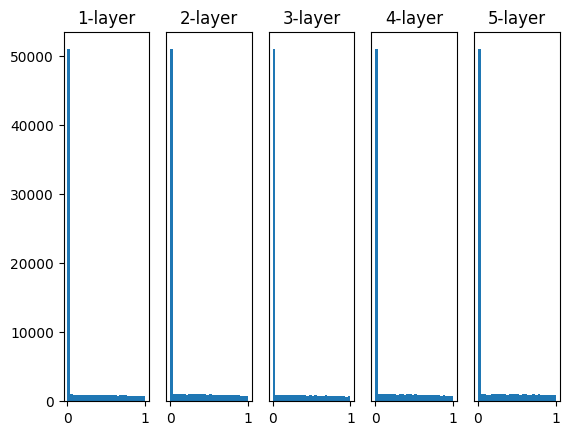

In [ ]:
# coding: utf-8
import numpy as np
import matplotlib.pyplot as plt


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def ReLU(x):
    return np.maximum(0, x)


def tanh(x):
    return np.tanh(x)


input_data = np.random.randn(1000, 100)  # 1000개의 데이터
node_num = 100  # 각 은닉층의 노드(뉴런) 수
hidden_layer_size = 5  # 은닉층이 5개
activations = {}  # 이곳에 활성화 결과를 저장

x = input_data

for i in range(hidden_layer_size):
    if i != 0:
        x = activations[i-1]

    # 초깃값을 다양하게 바꿔가며 실험해보자！
    # w = np.random.randn(node_num, node_num) * 1
    # w = np.random.randn(node_num, node_num) * 0.01
    #w = np.random.randn(node_num, node_num) * np.sqrt(1.0 / node_num)
    w = np.random.randn(node_num, node_num) * np.sqrt(2.0 / node_num)

    a = np.dot(x, w)

    # 활성화 함수도 바꿔가며 실험해보자！
    #z = sigmoid(a)
    z = ReLU(a)
    # z = tanh(a)

    activations[i] = z

# 히스토그램 그리기
for i, a in activations.items():
    plt.subplot(1, len(activations), i+1)
    plt.title(str(i+1) + "-layer")
    if i != 0:
        plt.yticks([], [])
    # plt.xlim(0.1, 1)
    # plt.ylim(0, 7000)
    plt.hist(a.flatten(), 30, range=(0, 1))

plt.show()

- 활성화값의 분포가 0과 1에 치우쳐져 있는 경우:

z = W * x + b
a = sigmoid(z)
로 결정되는 a가 활성화값인데

해당 값이 0이나 1에 치우쳐져 있을 경우 각 층에 들어가는 지난 층의 결과가 거의 변함이 없다는 것을 의미한다.

해당 의미는 100개의 뉴런이 있어도 1개처럼 작동한다는 의미


- 최적화된 활성화값의 분포:

활성화값은 전체적인 분포에 0과 1 사이에 고르게 퍼져있어야

→ 각 뉴런이 서로 다른 특징을 학습

→ 뉴런 100개가 100개 역할을 다 함

비에르 글로로트와 요슈아 벤지오의 논문에서 권장하는 가중치의 초깃값인, 일병 Xavier 초깃값을 사용해보도록 하겠습니다

- 현재 Xavier 초깃값은 일반적인 딥러닝 프레임워크들이 표준적으로 이용하고 있습니다.
- 예를 들어 카페 프레임워크는 가중치 초깃값을 설정할 때, 인수로 xavier를 지정할 수 있습니다.
- 이 논문은 각 층의 활성화값들을 광범위하게 분포시킬 목적으로 갖우치의 적절한 분포를 찾고자 했습니다. 그리고 앞 계층의 노드가 n개라면 표준편차가 1/ root(n)인 분포를 사용하면 된다는 결론을 이끌었습니다.

In [ ]:
node_num = 100
w = np.random.randn(node_num, node_num) * np.sqrt(1.0 / node_num)
# 이것이 xavier을 쓴 부분
# node_num이 많으면 1/ root(n)에서 n이 많아짐 -> 표준편차는 작아지게 됩니다.
# 표준 편차가 작아지면 데이터들이 평균에 모여있게 만들 수 있습니다.

# 반면 node_nume이 작으면 1/root(n)에서 n이 적어짐 -> 표준편차는 커짐
# 표준 편차가 커지면 데이터들이 평균에 모여있지 않고 퍼지게 됨

# 입력 데이터의 갯수에 따라서 활성화값의 분포를 조율할 수 있는 장점이 있다.

ReLu를 사용할 때의 가중치 초깃값

Xavier 초깃값은 활성화 함수가 선형이라는 전제로 이끈 결과입니다.

sigmoid 함수와 tanh함수는 좌우 대칭이라 중앙 부근이 선형인 함수로 볼 수 있죠.

그래서 Xavier 초깃값이 적당합니다.

반면, ReLu를 이용할 때에는 ReLU에 특화된 초깃값을 이용하라고 권장합니다.

-> He 초깃값을 사용

He 초깃값은 카이밍 하의 이름을 따서 지어졌으며, 앞 계층의 노드가 n개일 때, 표준편차가 root(2/n)인 정규분포를 사용합니다. Xavier초깃값이 root(1/n)이었던 것을 기억합시다!



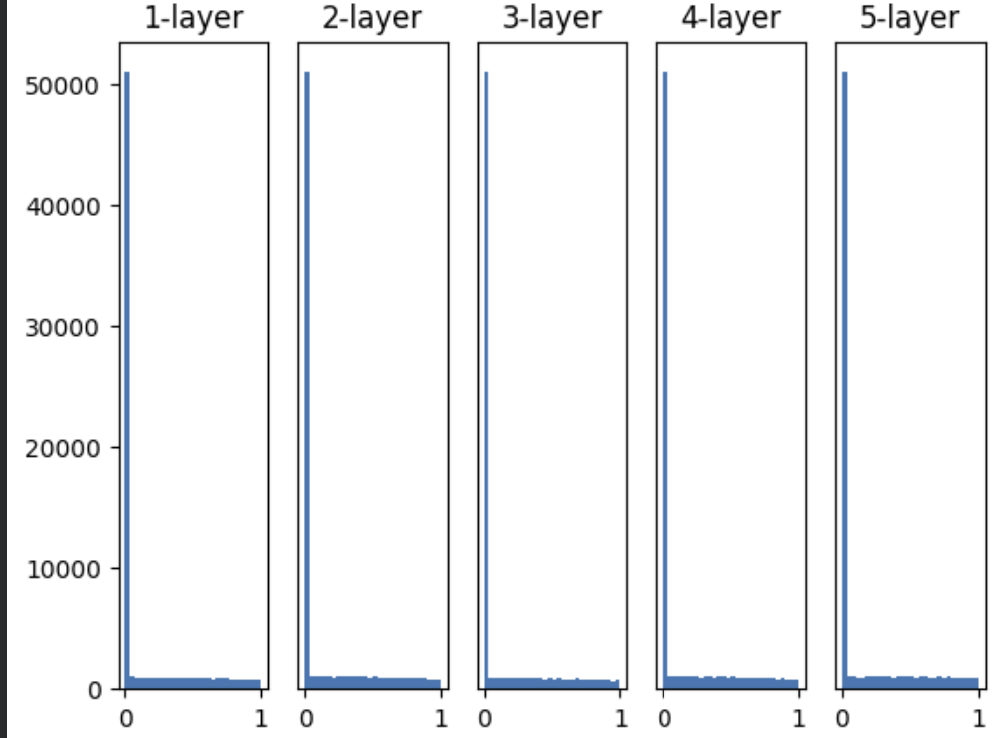

He 초깃값을 사용하며 ReLU함수를 활성함수로 사용했을 때에는 레이어가 깊어져도 일정하게 유지되는 것을 볼 수 있습니다. 즉, 모든 층에서 균일하게 분포되어 있다는 것입니다.

층이 깊어져도 분포가 균일하게 유지되기에 역전파 때도 적절한 값이 나올 것을 기대할 수 있습니다 .



ReLU함수에서 0값이 높게 나오는 이유:

    ReLU 함수가 0 이하의 값에서는 0을 출력하기 때문에 높을 수 밖에 없음
    0값을 제외하고 나머지는 고루게 분포하고 있음을 확인할 수 있음
    

균일하게 분포하고 있다 -> 각 layer에서

z = W * x + b

a = 활성화함수 (z)

a가 다음 층으로 넘어감

계속 반복 (forward - 순서대로 진행)

<역전파 개념>

예측값과 실제 정답 사이의 Loss를 구함

Loss의 분포에서 각 위치에서의 기울기를 구함

W = W - lr × 기울기

기울기 = 다음층에서 온 기울기 × a



## 전체 파이프라인

0. 초기화

가중치 W를 초기화

sigmoid/tanh → Xavier (1/루트n)

ReLU         → He     (2/루트n)

초기화를 잘 해야 활성화 값이 균일하게 분포

→ 순전파/역전파 모두 잘 작동

1. 순전파 (Forward)

mini batch 입력 x

↓

z = Wx + b          ← 선형 결합

↓

a = ReLU(z)         ← 활성화 함수 통과 (활성화 값)

↓

(층마다 반복)

↓

마지막 층 → softmax → 각 클래스의 확률 출력

예) 고양이 70%, 강아지 20%, 새 10%



2. Loss 계산

softmax 출력값 (예측) vs 실제 정답

→ 차이를 Loss (숫자 하나) 로 계산

Loss가 작을수록 잘 예측하고 있다는 뜻



3. 역전파 (Backward)

Loss를 미분 → 첫 번째 기울기

↓

뒤에서 앞으로 각 층마다:

기울기 = 앞에서 온 기울기 × 활성화함수 미분값 × a

↓

이 기울기를 또 앞 층으로 전달

↓

연쇄법칙으로 층마다 곱해가며 전달



4. 가중치 업데이트

W = W - lr × 기울기



기울기 방향의 반대로 W를 업데이트


lr(학습률)로 얼마나 크게 업데이트할지 조절



5. 반복

1~4 과정을 mini batch마다 반복


→ Loss가 점점 작아짐

→ 모델이 점점 정답에 가까워짐



전체를 한눈에

초기화 (Xavier / He)

↓

[순전파]

x → z=Wx+b → a=ReLU(z) → 반복 → softmax → 예측값

↓

[Loss 계산]

예측값 vs 정답 → Loss (숫자)

↓

[역전파]

Loss 미분 → 기울기를 뒤에서 앞으로 전달 (연쇄법칙)

↓

[가중치 업데이트]

W = W - lr × 기울기

↓

반복 → Loss 감소 → 학습 완료


In [ ]:
# coding: utf-8
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
sys.path.append(os.pardir)  # 부모 디렉터리의 파일을 가져올 수 있도록 설정
from dataset.mnist import load_mnist
from common.util import smooth_curve
from common.multi_layer_net import MultiLayerNet
from common.optimizer import SGD


# 0. MNIST 데이터 읽기==========
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

train_size = x_train.shape[0]
batch_size = 128
max_iterations = 2000


# 1. 실험용 설정==========
weight_init_types = {'std=0.01': 0.01, 'Xavier': 'sigmoid', 'He': 'relu'}
optimizer = SGD(lr=0.01)

networks = {}
train_loss = {}
for key, weight_type in weight_init_types.items():
    networks[key] = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100],
                                  output_size=10, weight_init_std=weight_type)
    train_loss[key] = []


# 2. 훈련 시작==========
for i in range(max_iterations):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    for key in weight_init_types.keys():
        grads = networks[key].gradient(x_batch, t_batch)
        optimizer.update(networks[key].params, grads)

        loss = networks[key].loss(x_batch, t_batch)
        train_loss[key].append(loss)

    if i % 100 == 0:
        print("===========" + "iteration:" + str(i) + "===========")
        for key in weight_init_types.keys():
            loss = networks[key].loss(x_batch, t_batch)
            print(key + ":" + str(loss))


# 3. 그래프 그리기==========
markers = {'std=0.01': 'o', 'Xavier': 's', 'He': 'D'}
x = np.arange(max_iterations)
for key in weight_init_types.keys():
    plt.plot(x, smooth_curve(train_loss[key]), marker=markers[key], markevery=100, label=key)
plt.xlabel("iterations")
plt.ylabel("loss")
plt.ylim(0, 2.5)
plt.legend()
plt.show()

ModuleNotFoundError: No module named 'dataset'

## 배치 정규화

배치 정규화를 사용하면 각 층이 활성화를 적당히 퍼뜨리도록 강제할 수 있습니다.

### 배치 정규화 알고리즘

- 2015년에 제안된 방법

배치 정규화가 주목받는 이유:

- 학습을 빨리 진행할 수 있다. (학습 속도 개선)
- 초깃값에 크게 의존하지 않는다
- 과대적합을 억제한다. (드롭 아웃 등의 필요성 감소)

이때 사용되는 개념이 Batch Norm!!!!!!!!!!!!

-> 데이터 분포를 정규화하는 '배치 정규화 계층'을 신경망에 삽입합니다.

Affine -> Batch Norm -> ReLU


    미니 배치의 평균과 분산을 구한 뒤,
    {(해당 값 xi ) - 평균} / root (분산 + 엡실론(작은 값 = 0으로 나누는 것을 방지)을 진행해서 새로운 xi에 대입

해당 과정을 거치고 나면 평균이 0, 분산이 1이 되게 정규화할 수 있습니다.

이 처리를 활성화 함수의 앞(혹은 뒤)에 삽입함으로써 데이터 분포가 덜 치우치게 할 수 있습니다.

또 배치 정규화 계층마다 이 정규화된 데이터에 고유한 확대와 이동 변환을 수행합니다.

yi <- Y* xi(정규화된 값) + B

Y가 확대, B가 이동을 담당

두 값은 처음에는 Y = 1, B= 0에서 시작하고 학습하면서 적합한 값으로 조정해나갑니다.

##### 확대와 이동을 하는 이유


z = W * x + b

이후 batch norm -> 평균을 0, 분산을 1로 지정하는 그래프형태로 변경

해당 값들은 0을 기준으로 모여있게 됨

이후 sigmoid 함수에 넣게 되면 0에 가까운 z값들을 sigmoid에 넣게 되면 값들의 분포가 별로 차가 나지 않는다.

뉴런들이 각각 다 같은(비슷한) 값들을 내놓게 되고

이러면 표현력을 잃게 됨


그래서 Y와 B가 하는 일

    0 근처에 몰린 값들을
    sigmoid의 비선형 구간으로 밀어줌
    ↓
    a값들이 다양하게 나옴
    ↓
    표현력 유지!

## 과대적합 방지 방법

- 가중치 감소


가중치 감소는 학습 과정에서 큰 가중치에 대해서는 그에 상응하는 큰 페널티를 부과하여 과대적합을 억제하는 방법입니다.

원래 과대적합은 가중치 매개변수의 값이 커서 발생하는 경우가 많기 때문입니다.

가중치= [1,2,3] 이라고 한다면 root (1^2 + 2^2 + 3^2 )를 하여 가중치의 제곱 노름 (norm)을 만들고 이를 손실함수에 더합니다.

Loss += (norm) 을 적용하여 Loss의 값을 크게 만들고 Loss가 크므로 가중치를 더 작게 만들어야 한다고 하므로 가중치를 커지는 현상을 억제할 수 있습니다.

norm은 보통 1/2 (람다)(W^2)으로 만드는데 정리하면 다음과 같습니다.

Loss = Loss + 1/2(람다)(W^2)

이때 람다의 값은 하이퍼 파라미터로 우리가 조절할 수 있습니다.

람다를 큰 값으로 두면 Loss의 값이 커집니다. Loss가 크므로 역전파시, W의 값을 강하게 억제 합니다.  ex. 람다 = 1

반면, 람다를 작은 값 (ex, 0.001)으로 두면 Loss의 값이 소폭 증가하므로, W의 값을 약하게 억제합니다.

람다가 0인 경우, Loss의 값은 변화가 없기 때문에 람다가 없을 때와 같은 결과를 도출하게 됩니다.

가중치 감소는 모든 가중치 각각의 손실 함수에 (1/2)λW²을 더합니다. 따라서 가중치의 기울기를 구하는 계산에서는 그동안의 오차역전파법에 따른 결과에 정규화 항을 미분한 λW를 더합니다.



In [1]:
import sys, os
sys.path.append(os.pardir)  # 부모 디렉터리의 파일을 가져올 수 있도록 설정
import numpy as np
from collections import OrderedDict
from common.layers import *
from common.gradient import numerical_gradient


class MultiLayerNet:
    """완전연결 다층 신경망

    Parameters
    ----------
    input_size : 입력 크기（MNIST의 경우엔 784）
    hidden_size_list : 각 은닉층의 뉴런 수를 담은 리스트（e.g. [100, 100, 100]）
    output_size : 출력 크기（MNIST의 경우엔 10）
    activation : 활성화 함수 - 'relu' 혹은 'sigmoid'
    weight_init_std : 가중치의 표준편차 지정（e.g. 0.01）
        'relu'나 'he'로 지정하면 'He 초깃값'으로 설정
        'sigmoid'나 'xavier'로 지정하면 'Xavier 초깃값'으로 설정
    weight_decay_lambda : 가중치 감소(L2 법칙)의 세기
    """
    def __init__(self, input_size, hidden_size_list, output_size,
                 activation='relu', weight_init_std='relu', weight_decay_lambda=0):
        self.input_size = input_size
        self.output_size = output_size
        self.hidden_size_list = hidden_size_list
        self.hidden_layer_num = len(hidden_size_list)
        self.weight_decay_lambda = weight_decay_lambda
        self.params = {}

        # 가중치 초기화
        self.__init_weight(weight_init_std)

        # 계층 생성
        activation_layer = {'sigmoid': Sigmoid, 'relu': Relu}
        self.layers = OrderedDict()
        for idx in range(1, self.hidden_layer_num+1):
            self.layers['Affine' + str(idx)] = Affine(self.params['W' + str(idx)],
                                                      self.params['b' + str(idx)])
            self.layers['Activation_function' + str(idx)] = activation_layer[activation]()

        idx = self.hidden_layer_num + 1
        self.layers['Affine' + str(idx)] = Affine(self.params['W' + str(idx)],
            self.params['b' + str(idx)])

        self.last_layer = SoftmaxWithLoss()

    def __init_weight(self, weight_init_std):
        """가중치 초기화

        Parameters
        ----------
        weight_init_std : 가중치의 표준편차 지정（e.g. 0.01）
            'relu'나 'he'로 지정하면 'He 초깃값'으로 설정
            'sigmoid'나 'xavier'로 지정하면 'Xavier 초깃값'으로 설정
        """
        all_size_list = [self.input_size] + self.hidden_size_list + [self.output_size]
        for idx in range(1, len(all_size_list)):
            scale = weight_init_std
            if str(weight_init_std).lower() in ('relu', 'he'):
                scale = np.sqrt(2.0 / all_size_list[idx - 1])  # ReLU를 사용할 때의 권장 초깃값
            elif str(weight_init_std).lower() in ('sigmoid', 'xavier'):
                scale = np.sqrt(1.0 / all_size_list[idx - 1])  # sigmoid를 사용할 때의 권장 초깃값
            self.params['W' + str(idx)] = scale * np.random.randn(all_size_list[idx-1], all_size_list[idx])
            self.params['b' + str(idx)] = np.zeros(all_size_list[idx])

    def predict(self, x):
        for layer in self.layers.values():
            x = layer.forward(x)

        return x

    def loss(self, x, t):
        """손실 함수를 구한다.

        Parameters
        ----------
        x : 입력 데이터
        t : 정답 레이블

        Returns
        -------
        손실 함수의 값
        """
        y = self.predict(x)

        weight_decay = 0
        for idx in range(1, self.hidden_layer_num + 2):
            W = self.params['W' + str(idx)]
            weight_decay += 0.5 * self.weight_decay_lambda * np.sum(W ** 2)

        return self.last_layer.forward(y, t) + weight_decay

    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis=1)
        if t.ndim != 1 : t = np.argmax(t, axis=1)

        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy

    def numerical_gradient(self, x, t):
        """기울기를 구한다(수치 미분).

        Parameters
        ----------
        x : 입력 데이터
        t : 정답 레이블

        Returns
        -------
        각 층의 기울기를 담은 딕셔너리(dictionary) 변수
            grads['W1']、grads['W2']、... 각 층의 가중치
            grads['b1']、grads['b2']、... 각 층의 편향
        """
        loss_W = lambda W: self.loss(x, t)

        grads = {}
        for idx in range(1, self.hidden_layer_num+2):
            grads['W' + str(idx)] = numerical_gradient(loss_W, self.params['W' + str(idx)])
            grads['b' + str(idx)] = numerical_gradient(loss_W, self.params['b' + str(idx)])

        return grads

    def gradient(self, x, t):
        """기울기를 구한다(오차역전파법).

        Parameters
        ----------
        x : 입력 데이터
        t : 정답 레이블

        Returns
        -------
        각 층의 기울기를 담은 딕셔너리(dictionary) 변수
            grads['W1']、grads['W2']、... 각 층의 가중치
            grads['b1']、grads['b2']、... 각 층의 편향
        """
        # forward
        self.loss(x, t)

        # backward
        dout = 1
        dout = self.last_layer.backward(dout)

        layers = list(self.layers.values())
        layers.reverse()
        for layer in layers:
            dout = layer.backward(dout)

        # 결과 저장
        grads = {}
        for idx in range(1, self.hidden_layer_num+2):
            grads['W' + str(idx)] = self.layers['Affine' + str(idx)].dW + self.weight_decay_lambda * self.layers['Affine' + str(idx)].W
            grads['b' + str(idx)] = self.layers['Affine' + str(idx)].db

        return grads

ModuleNotFoundError: No module named 'common'

In [ ]:
import os
import sys

sys.path.append(os.pardir)  # 부모 디렉터리의 파일을 가져올 수 있도록 설정
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net import MultiLayerNet
from common.optimizer import SGD

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 오버피팅을 재현하기 위해 학습 데이터 수를 줄임
x_train = x_train[:300]
t_train = t_train[:300]

# weight decay（가중치 감쇠） 설정 =======================
#weight_decay_lambda = 0 # weight decay를 사용하지 않을 경우
weight_decay_lambda = 0.1
# ====================================================

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=weight_decay_lambda)
optimizer = SGD(lr=0.01) # 학습률이 0.01인 SGD로 매개변수 갱신

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


# 그래프 그리기==========
markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

## 드롭 아웃

앞서 설명한 가중치 감소는 간단하게 구현할 수 있고 어느 정도 지나친 학습을 억제할 수 있습니다. 그러나 신경망 모델이 복잡해지면서 가중치 감소만으로는 대응하기 어려워집니다.

이럴 때 흔히 드롭 아웃이라는 기법을 사용합니다.

드롭 아웃은 뉴런을 임의로 삭제하면서 학습하는 방법입니다. 훈련 때 은닉층의 뉴런을 무작위로 골라 삭제합니다. 삭제된 뉴런은 신호를 전달하지 않게 됩니다.

훈련 때는 데이터를 흘릴 때마다 삭제할 뉴런을 무작위로 선택하고, 시험 때는 모든 뉴런에 신호를 전달합니다.

단, 시험때는 각 뉴런의 출력에 훈련 때 삭제 안한 비율을 곱하여 출력합니다



In [2]:
class Dropout:
    def __init__(self, dropout_ratio = 0.5):
        self.dropout_ratio = dropout_ratio
        self.mask = None

    def forward(self, x, train_flg = True):
        if train_flg:
            self.mask= np.random.rand(*x.shape) > self.dropout_ratio
            return x * self.mask
        else:
            return x * (1.0 - self.dropout_ratio)

    def backward (self, dout):
        return dout * self.mask

위 코드의 핵심은 훈련 시에는 순전파 때마다 self.mask에 삭제할 뉴런을 False로 표시한다는 점입니다. self.mask는 x와 형상이 같은 배열을 무작위로 생성하고, 그 값이 dropout_ratio보다 큰 원소만 True로 설정합니다.

역전파 때의 동작은 ReLU와 같습니다.  즉, 순전파 때 신호를 통과시키는 뉴런은 역전파 때도 신호를 그대로 통과시키고, 순전파 때 통과시키지 않은 뉴런은 역전파 때도 신호를 차단합니다.

머신 러닝에서는 앙상블 학습을 애용합니다. 앙상블 학습은 개별적으로 학습시킨 여러 모델의 출력을 평균 내어 추론하는 방식입니다.

신경망의 맥락에서 얘기하면 가령 같은 (혹은 비슷한) 구조의 신경망을 5개 준비하여 따로따로 학습시키고 시험때는 그 5개의 출력을 평균 내어 답하는 것입니다.

앙상블 학습을 수행하면 신경망의 정확도가 몇 % 정도 개선된다는 사실이 실험적으로 알려져 있습니다.

앙상블 학습은 드롭 아웃과 밀접합니다. 드롭 아웃이 학습 때 뉴런을 무작위로 삭제하는 행위를 매번 다른 모델을 학습시키는 것으로 해석할 수 있기 때문입니다.

그리고 추론 대는 뉴런의 출력에 삭제하지 않은 비율(ex, 0.5 등)을 곱함으로써 앙상블 학습에서 여러 모델의 평균을 낼 때와 같은 효과를 얻는 것입니다. 즉, 드롭 아웃은 앙상블 학습과 같은 효고라르 대략 하나의 신경망으로 구현했다고 생각할 수 있습니다.

## 하이퍼 파라미터 값 찾기

validation 테스트 셋으로 train된 데이터를 검증할 때 사용합니다.
주로 train dataset, validation dataset, test dataset으로 구분되며,

test dataset은 가급적 마지막에 한번만 이용합니다.

시험 데이터를 사용하여 하이퍼파라미터를 조정하면 하이퍼파라미터 값이 시험 데이터에 과대적합 됩니다.

하이퍼파라미터 값의 '좋음'을 시험 데이터로 확인하게 되므로 하이퍼 파라미터의 값이 시험 데이터에만 적합하도록 조정되어 버립니다.

그렇게 되면 다른 데이터에는 적응하지 못하니 범용 성능이 떨어지는 모델일 될 수 있습니다.

    하이퍼 파라미터의 값을 test dataset에 맞추게 되면, 해당 dataset에는 좋은 결과를 낼 수 있겠지만,  
    다른 상황에서는 좋은 모델이 나오기 어려워집니다.

In [3]:
#train dataset의 20% 정도를 검증 데이터로 분리합니다.

(x_train, t_train), (x_test, t_test)= load_mnist()

#훈련 데이터를 뒤섞습니다.
x_train, t_train= shuffle_dataset(x_train, t_train)

#20%를 검증 데이터로 분할
validataion_rate = 0.20
validataion_num = int(x_train.shape[0] * validataion_rate)

x_val = x_train[:validataion_num]
t_val = t_train[:validataion_num]
x_train = x_train[validataion_num:]
t_val = t_train[validataion_num:]

NameError: name 'load_mnist' is not defined

## 하이퍼파라미터의 최적화 방법!!!

핵심: 하이퍼파라미터의 최적 값이 존재하는 범위를 조금씩 줄여가는 방법

1. 대략적인 범위를 설정
2. 그 범위에서 무작위로 하이퍼파라미터 값을 골라낸(샘플링) 후, 그 값으로 정확도를 평가합니다.

3. 찾을 때까지 반복

신경망의 하이퍼파라미터 최적화에서는 그리드 서치 같은 규치적인 탐색보다는 무작위로 샘플링해 탐색하는 편이 좋은 결과를 낸다고 알려져 있습니다. 이는 최종 정확도에 미치는 영향력이 하이퍼파라미터마다 다르기 때문입니다.

실제로도 0.001에서 1.000 사이와 같이 10의 거듭제곱 단위로 지정합니다.
이를 "로그 스케일로 지정"한다고 합니다

하이퍼파라미터를 최적화할 때는 딥러닝 학습ㅇ는 오랜 시간 (며칠이나 몇 주이상)이 걸린다는 점이 있습니다.

따라서 나쁠 듯한 값은 일찍 포기하는 것이 좋습니다. 그래서 학습을 위한 에포크를 작게 하여, 1회 평가에 걸리는 시간을 단축하는 편이 효과적입니다.

0.001~1.000 사이 같은 로그 스케일 범위에서 무작위로 추출해서 수행해봅니다.

이를 파이썬 코드로는 10 ** np.random.uniform(-3, 3)처럼 작성할 수 있습니다.

In [4]:
#하이퍼파라미터의 무작위 추출 코드
weight_decay  =10 ** np.random.uniform(-8,-4) #가중치 감소 계수를 10^-8~ 10*-4의 값 사이로 지정
lr = 10 ** np.random.uniform(-6, -2)    #학습률을 10^-6~10^-2 사이 값으로 지정